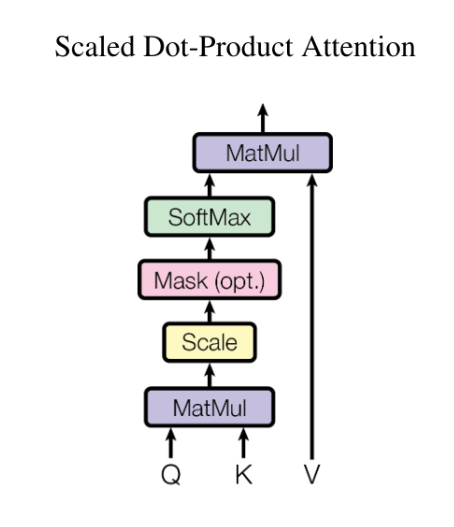

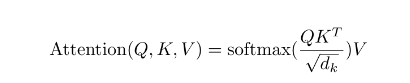

**1. The input consists of queries and keys of dimension dk**



q:d_k
k:d_k

**values of dimensions**

Basically we compute the dot product of query with all keys, divide each by root(dk), and phir apply kro softmax function ko inorder to obtain weights on the values

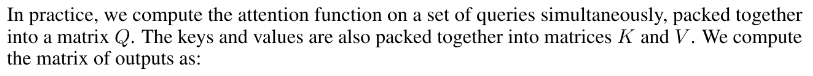

q: mtlb what i am looking for <br>
k: mtlb what i can offer <br>
values: mtlb mere pass asal me kya hai deneke liye

In [51]:
#Pratical Example

# The animal didn't cross the street because it was too tired

i want to know the context of "it" so how do we know ki ye actual me ye kis kis ko refer krega

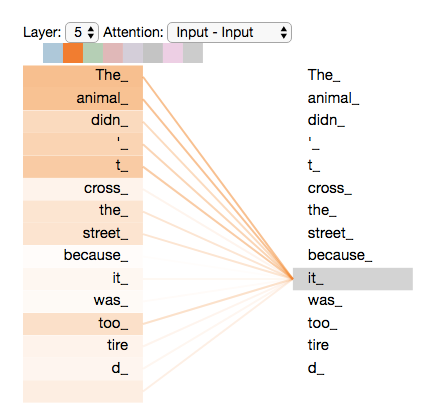

# **Why it is called as Self Attention?**

Self-attention (used in Transformer architecture models) is called “self” attention because the model computes attention within the same sequence.

Sentence:
“The animal didn’t cross the street because it was tired.”

The word “it” needs to know what it refers to.

With self-attention:

“it” attends to “animal”

It gives higher weight to animal than to street.

So the model learns:



```
it → animal (high attention)
it → street (low attention)
```

This happens inside the same sentence, so it is called self-attention.

Why not just “attention”?

Earlier attention (in seq2seq models like Attention mechanism used with Recurrent Neural Networks) worked like this:

Decoder attends to encoder outputs

So attention happened between two different sequences:


```
decoder → encoder
```

But in self attention
```
sequence → same sequence
```

Each token attend to all tokens including itself



In [52]:
import numpy as np


# Single self attention to bhai phir bhi thik hai but wo research paper also "Attention is all you need" me multi head attention use hua hai

In [53]:
# d_k=d_v=d_model

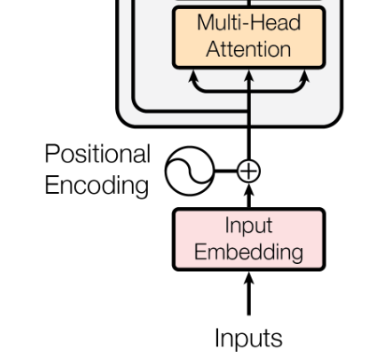

In [54]:
#aar model is 512 dimension hai and mera sentence hai uska maxm length=11
'''
basicallly 11 rows haia nd usme 512 dimensions hai
hum confuse nhi hona chahte since humlog samajh rhe to i am assuming to be 6, instead of 512
'''

'\nbasicallly 11 rows haia nd usme 512 dimensions hai\nhum confuse nhi hona chahte since humlog samajh rhe to i am assuming to be 6, instead of 512\n'

max_sequence_length=11<br>
L=11

In [55]:
L,d_k,d_v=11,6,6

In [56]:
q=np.random.randn(L,d_k)
k=np.random.randn(L,d_k)
v=np.random.randn(L,d_v)
#L mtlb sequnce ki length
#y basically np me se random dega and rand ke badd me n ilkha hai to iska mtlb ye hota ki ye r=nromal distrubution se sampling krega iska

In [57]:
q

array([[-0.25881281,  0.17632283, -2.69722712,  0.08895071,  0.93984191,
        -1.14345012],
       [-0.55809762,  0.24891565,  0.59343586, -0.79943597,  3.03197468,
         0.58595536],
       [-0.45540607, -2.5442023 ,  1.41310984,  0.14498421, -0.75479596,
         1.29469937],
       [ 0.22322152,  0.66100928, -0.74292966, -0.50365902, -0.6872845 ,
        -0.06025128],
       [-2.15880754, -0.26718888, -0.60498097, -0.77325501,  1.18396743,
        -0.61090626],
       [-0.94365138,  2.77937243, -0.58562016, -0.7169626 ,  1.33518945,
         0.25815864],
       [ 0.24123452,  0.19790105, -0.76157077,  0.96904714,  2.15207064,
        -0.11391915],
       [ 0.73618103, -1.27021161,  0.07131372,  0.16269279, -0.47983991,
        -1.31069374],
       [ 0.27933955,  1.85027926, -0.55667916, -0.04064053,  2.36420834,
         1.57703946],
       [ 0.30602226, -1.30522335, -1.58959462,  0.48249645, -1.00776966,
         0.23465843],
       [ 2.31227749,  0.10779419,  1.52692725, -1.

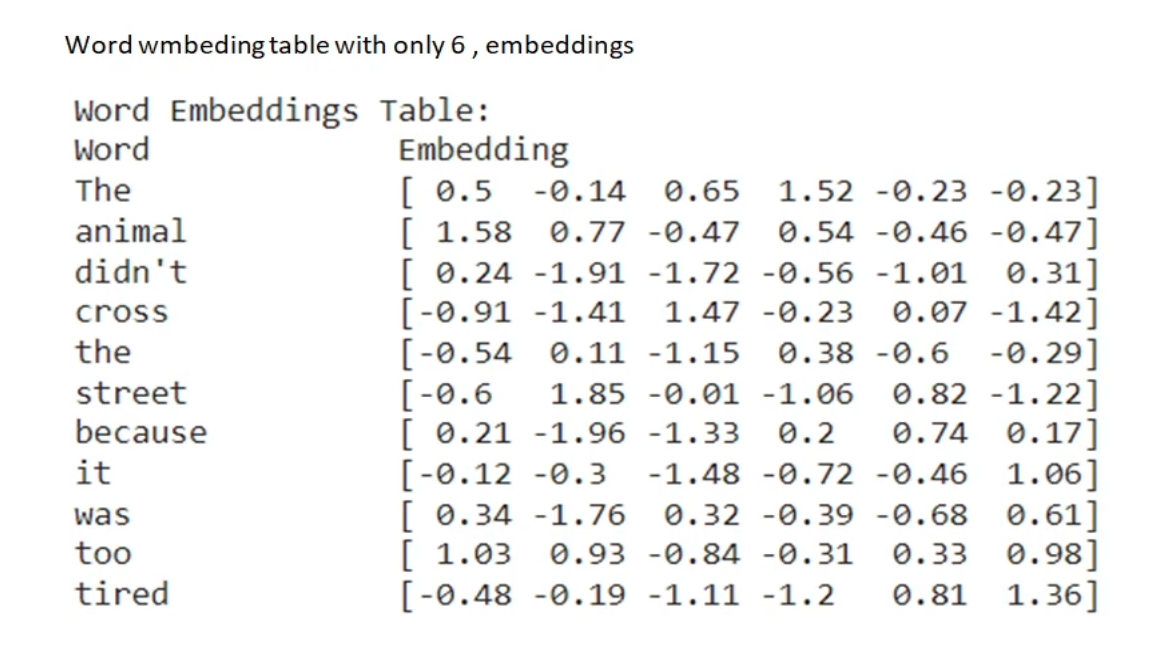

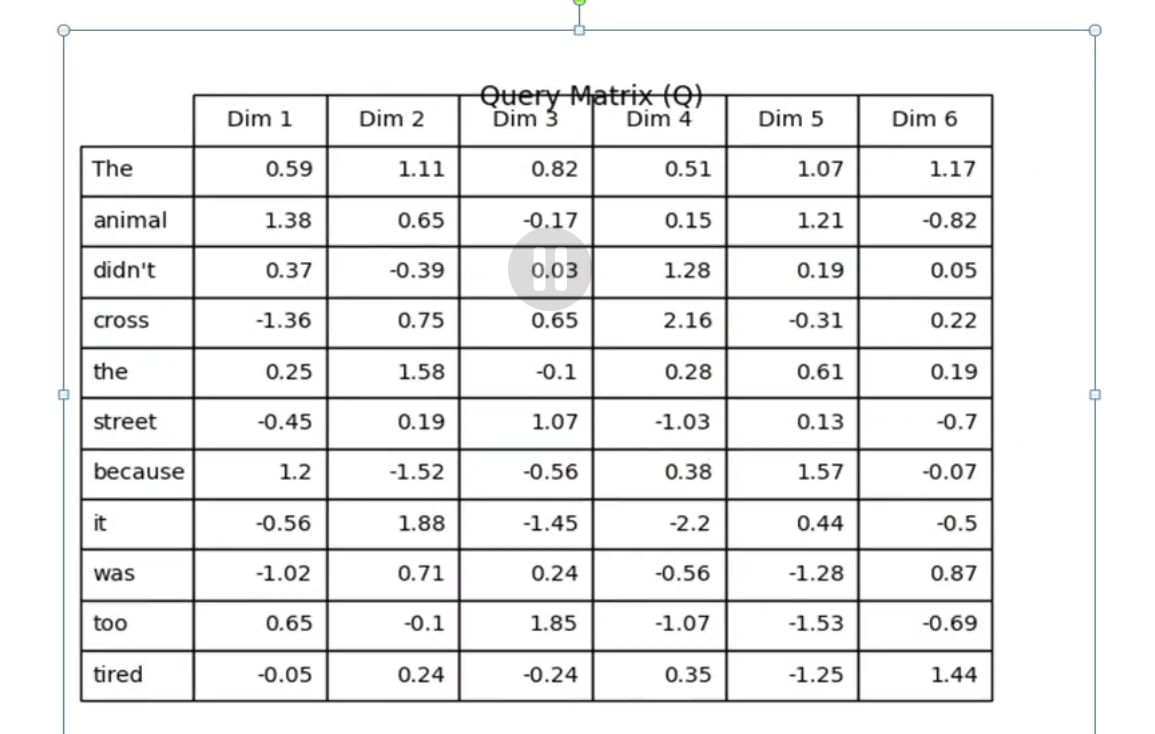

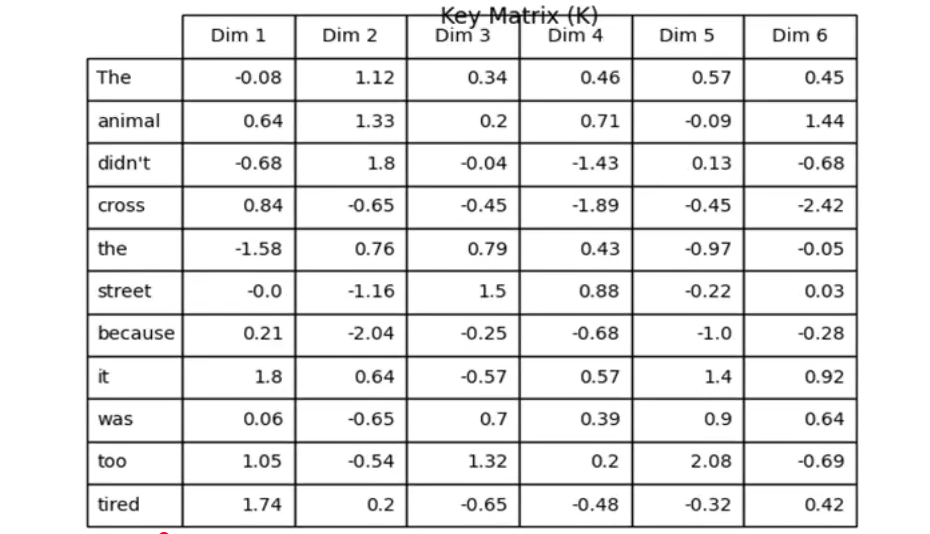

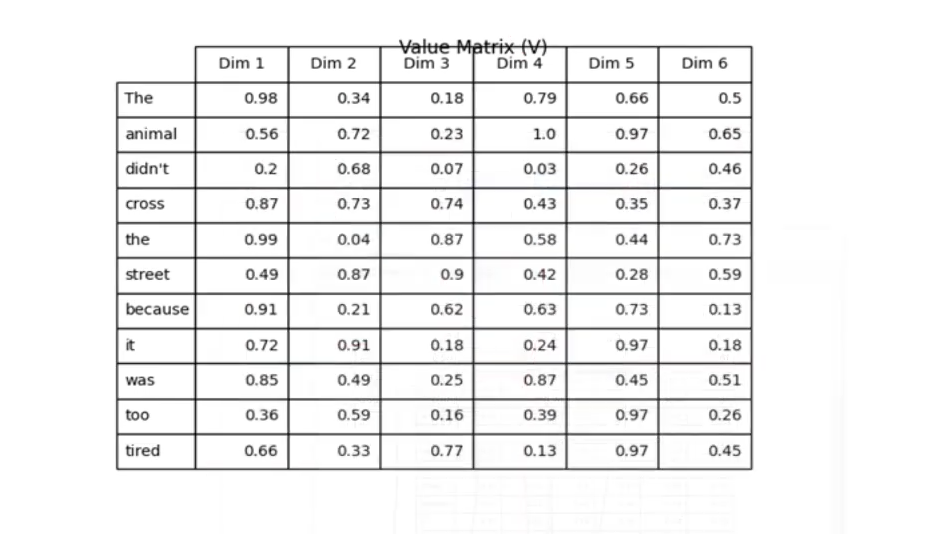

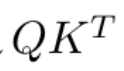

Since i have all three matrix like photo dekho , why it is multiplying??
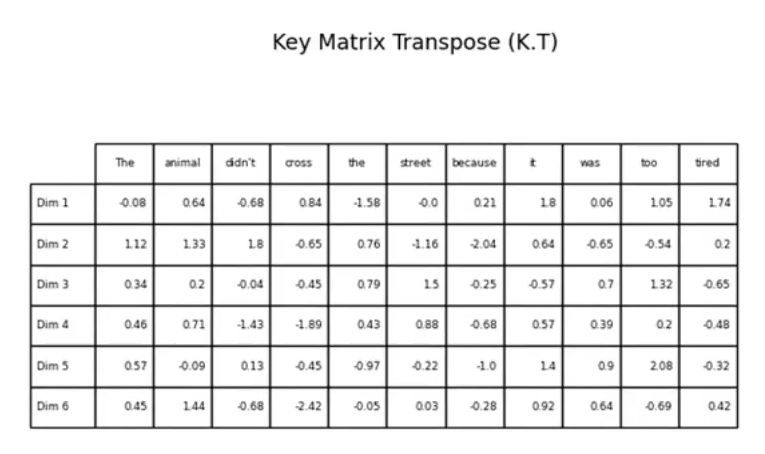

In [58]:
q.shape

(11, 6)

In [59]:
k.shape

(11, 6)

In [60]:
k=k.T

In [61]:
print(k.shape)

(6, 11)


In [62]:
o=np.matmul(q,k)

In [63]:
o.shape

(11, 11)

 Q.KT matrix hume relevancy batati hai, agar koi high similarity hui to bada number aayega, else chota number aayega

 Query->sab ko dekhega

 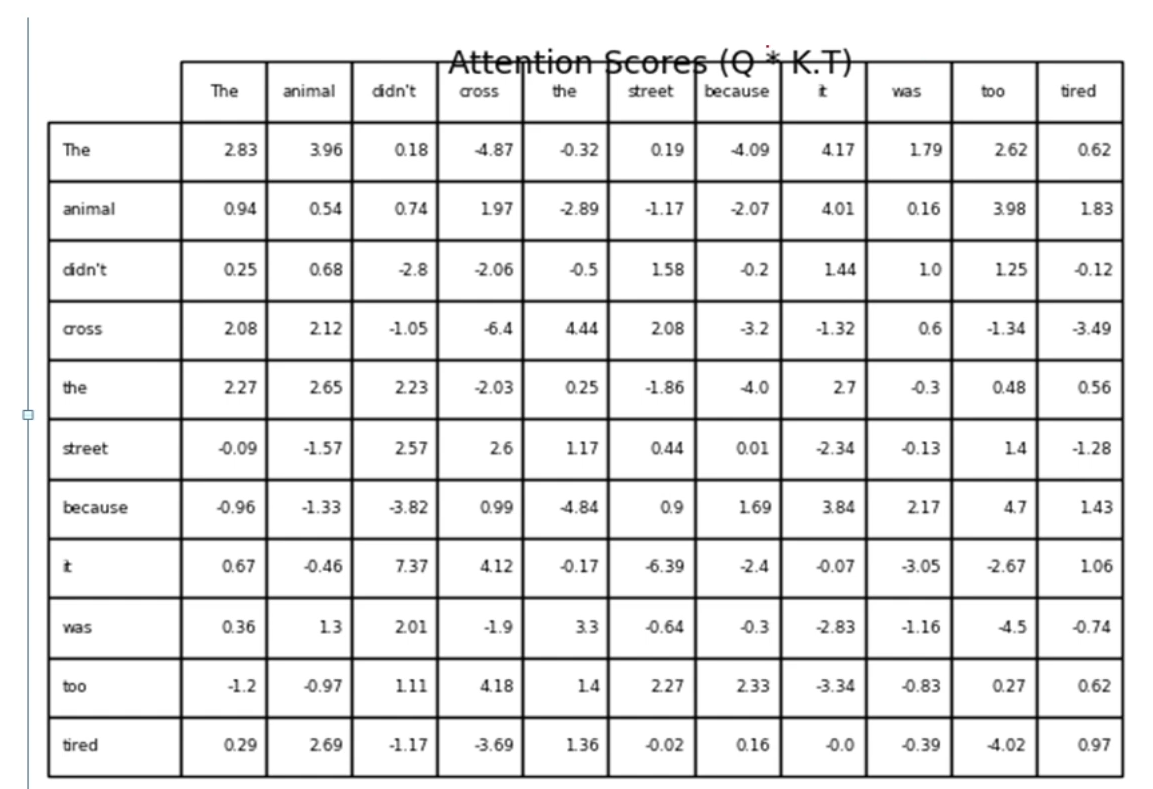

ab HUme attention score pata chal gaya ki kon kiske saath kitna milta hai

In [64]:
k=k.T
print(k.shape)

(11, 6)


In [65]:
q.var(),k.var(),np.matmul(q,k.T).var()
#variance se umlog pata krte hai ki mean ka data kitna spread hai


(np.float64(1.3839891113058975),
 np.float64(0.8332040550897606),
 np.float64(6.62192801936511))

In [66]:
#since, q and k are variance bhut chota hais ince spread acha hai but np.matmul(q,k.T) ka vairnce bahut bada hai since hume chota chota chahiye so hum usko chota krenge first ko all isliye hum root(dk) se divide krte hai

ye paper me bhi likha hai ki we suspect that for the large values of dk, the dt products grow large in magnitude, pushing the softmax function into regions where it has extremely small gradients


In [67]:
print(q.shape,k.shape)

(11, 6) (11, 6)


In [68]:
scaled=np.matmul(q,k.T)

Variance- basically data spread hona

In [69]:
q.var(),k.var(),scaled.var()

(np.float64(1.3839891113058975),
 np.float64(0.8332040550897606),
 np.float64(6.62192801936511))

In [70]:
import math
scaled=scaled/math.sqrt(d_k)

In [71]:
print(q.var(),k.var(),scaled.var())

1.3839891113058975 0.8332040550897606 1.103654669894185


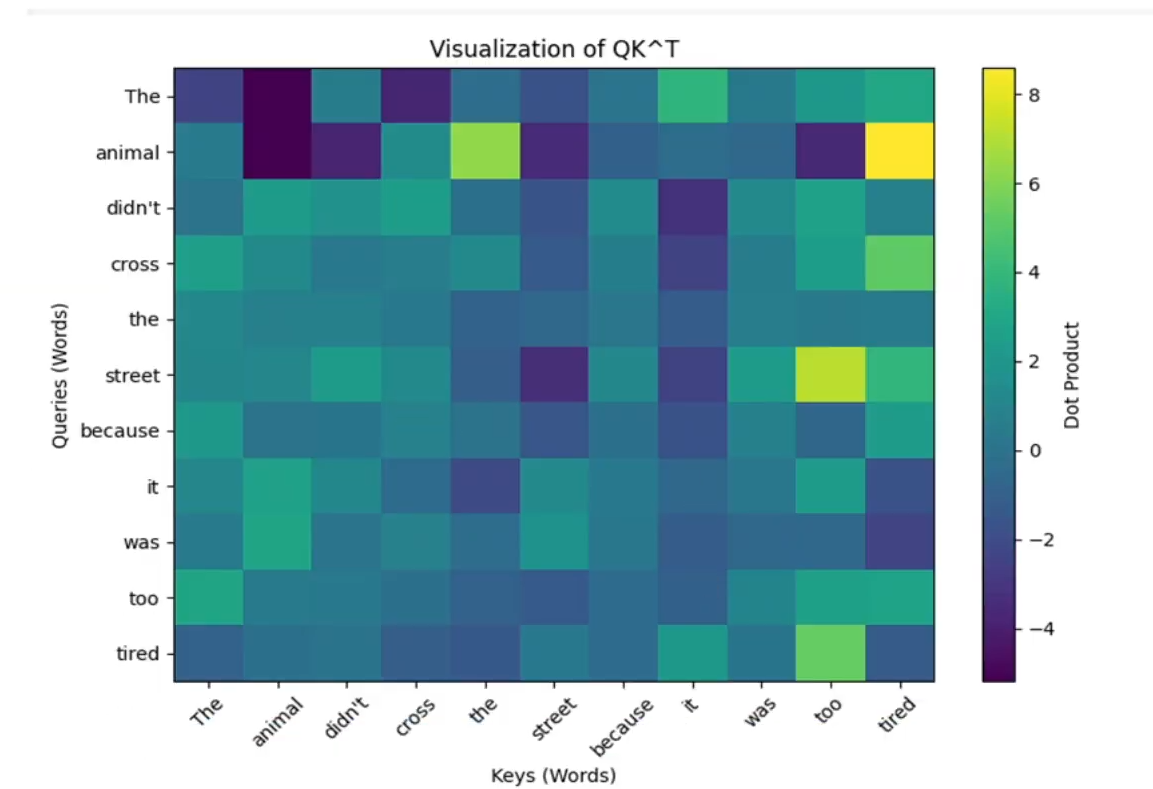

8-Highest Attention<br>
4-Lowest Attention

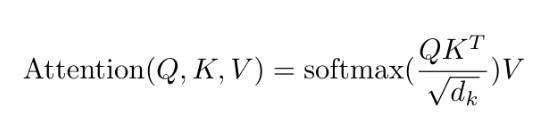

Now ab mereko softmax lagana hai ispe
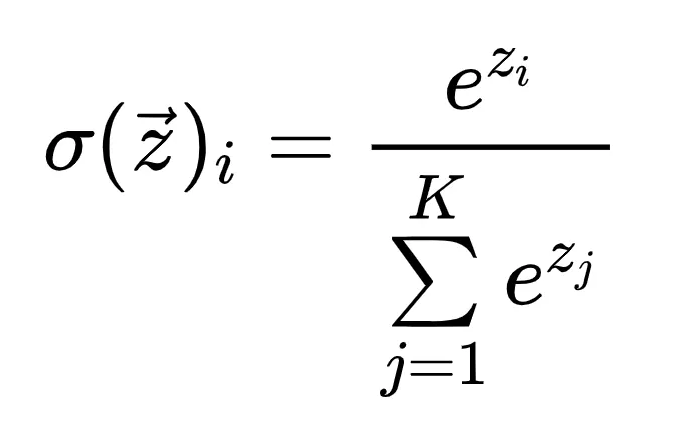

In [72]:
def softmax(x):
  return (np.exp(x).T/np.sum(np.exp(x),axis=-1)).T

In [73]:
attention=softmax(scaled)
attention

array([[0.04132199, 0.09686363, 0.0845182 , 0.17516582, 0.06195574,
        0.14143082, 0.03811269, 0.00343509, 0.17562418, 0.06419589,
        0.11737596],
       [0.00651675, 0.02579285, 0.04367294, 0.06341963, 0.04534824,
        0.02174196, 0.10099116, 0.12538114, 0.06038005, 0.42517823,
        0.08157705],
       [0.13707992, 0.02371134, 0.02005337, 0.019644  , 0.467597  ,
        0.03513974, 0.0224443 , 0.0921223 , 0.1029812 , 0.05290929,
        0.02631754],
       [0.21490519, 0.07466267, 0.08854218, 0.14595976, 0.05233957,
        0.11097466, 0.06674006, 0.08301552, 0.05904196, 0.04457747,
        0.05924094],
       [0.03813016, 0.08733073, 0.168577  , 0.0351389 , 0.09954777,
        0.04673822, 0.01072513, 0.01795029, 0.15314618, 0.25412557,
        0.08859005],
       [0.02355819, 0.09444725, 0.21059451, 0.15566347, 0.00915052,
        0.04453429, 0.06663536, 0.13536333, 0.01690367, 0.16136364,
        0.08178577],
       [0.00675231, 0.08381554, 0.05596633, 0.12320317, 0.

Softmax saaro ko ek range me le aata hai like [0,1] ke beech mein
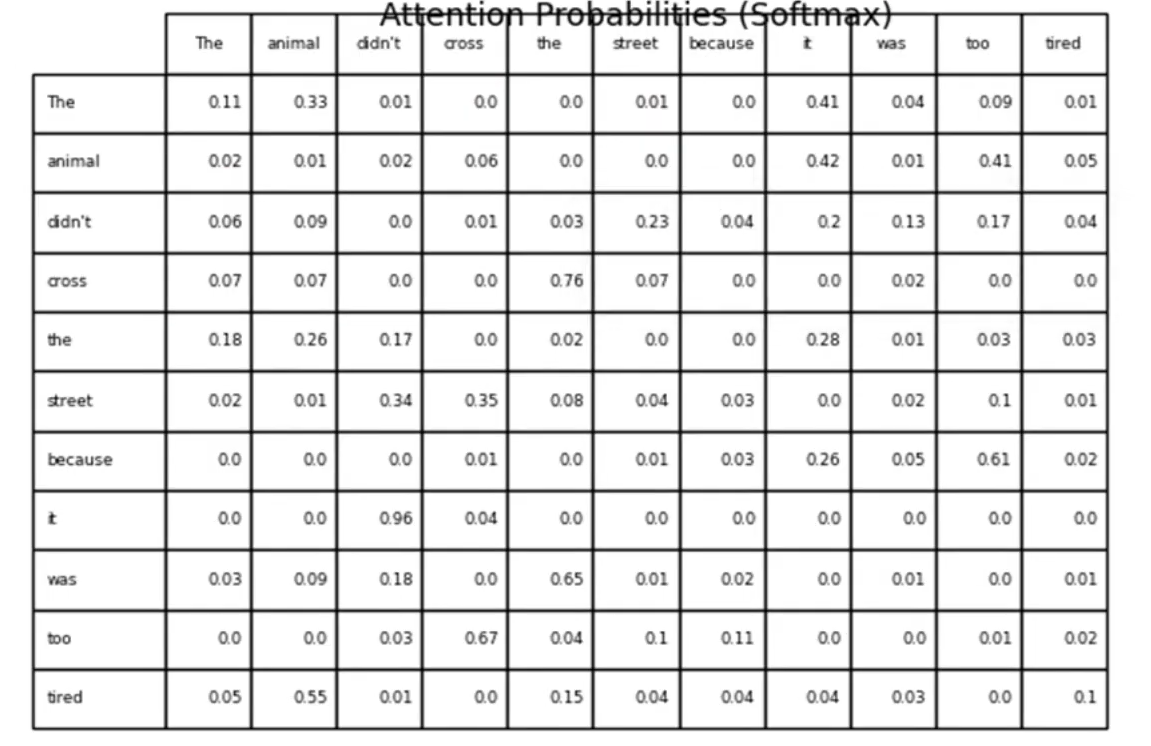

In [74]:
# Q.KT is only for similarity phir wo root dk is for making it euqal spread of data like variance check kroge to
#Q.KT ka variance hi sbse jyada hoga else humlog kya krenge ki isko equal spread krenge so
#uske liye root dk se divide krenge
#phir uske baad softmax laga denge


In [75]:
new_v=np.matmul(attention,v)
new_v

array([[-0.05642719,  0.18119412,  0.47622226,  0.6801838 ,  0.01568032,
         0.2335794 ],
       [-0.15543418,  0.1794448 , -0.05767623,  0.37036209,  0.41663263,
        -0.15934341],
       [ 0.35451008, -0.3757217 , -0.29991213,  0.38143299,  0.96457992,
        -0.32726484],
       [ 0.11843024,  0.24943385,  0.09687208,  0.69019112,  0.08638213,
         0.29865463],
       [-0.01138668,  0.4814822 ,  0.24021123,  0.49173594,  0.30645107,
         0.0029897 ],
       [-0.14230682,  0.52643232,  0.37259217,  0.60715099, -0.07978282,
         0.10189517],
       [-0.19909362,  0.11865095,  0.28608793,  0.4956979 ,  0.32687386,
         0.23514017],
       [ 0.14318918, -0.05469726,  0.07605834,  0.65694475,  0.37655554,
        -0.01018096],
       [-0.55447926, -0.06267951,  0.18144391,  0.58908697,  0.01232461,
         0.32659703],
       [ 0.2010604 , -0.001158  , -0.00545515,  0.62800333,  0.40132664,
         0.21136411],
       [ 0.57641292, -0.79489874, -0.51657717,  0.

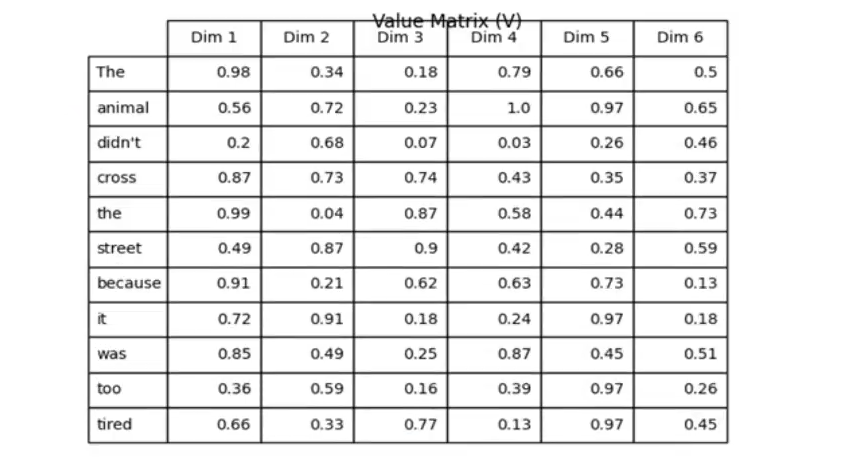